Базовый граф.

In [ ]:
class Vertex:
    def __init__(self, key):
        self.key = key
        self.edges = {}

    def add_edge(self, to_vertex, weight=1):
        self.edges[to_vertex] = weight

    def get_edges(self):
        return self.edges

    def __repr__(self):
        return f"Vertex({self.key})"


class Graph:
    def __init__(self):
        self.vertices = {}

    def addVertex(self, vert):
        if isinstance(vert, Vertex):
            self.vertices[vert.key] = vert
        else:
            raise TypeError("addVertex ожидает объект типа Vertex")

    def addEdge(self, fromVert, toVert, weight=1):
        if fromVert not in self.vertices:
            self.addVertex(Vertex(fromVert))
        if toVert not in self.vertices:
            self.addVertex(Vertex(toVert))
        self.vertices[fromVert].add_edge(toVert, weight)

    def getVertex(self, vertKey):
        return self.vertices.get(vertKey, None)

    def getVertices(self):
        return list(self.vertices.keys())

    def __contains__(self, vertKey):
        return vertKey in self.vertices

    def __repr__(self):
        return f"Graph({self.vertices})"



Все вершины графа: ['A', 'B', 'C']
Содержит 'A'? True
Содержит 'D'? False
Вершина 'B': Vertex(B)
Ребра вершины 'B': {'C': 5}


№ 1
(2 балла)
В примере алгоритма поиска в ширину из лекции
(https://cloud.mail.ru/public/9yCy/LitbGAfEg) структура данных граф представлена
словарем. Переделайте этот пример, заменив словарь на реализацию класса Graph из
лекционных материалов.


In [4]:
from collections import deque


def person_is_seller(name):
    return name[0].lower() == 'a'

def search(graph, start):
    search_queue = deque()
    start_vertex = graph.getVertex(start)
    if start_vertex is None:
        return False

    search_queue += start_vertex.get_edges()
    searched = set()

    while search_queue:
        person = search_queue.popleft()
        if person not in searched:
            if person_is_seller(person):
                print(person + " is a mango seller!")
                return True
            else:
                person_vertex = graph.getVertex(person)
                if person_vertex:
                    search_queue += person_vertex.get_edges()
                searched.add(person)
    return False

g = Graph()
g.addEdge("you", "alice")
g.addEdge("you", "bob")
g.addEdge("you", "claire")
g.addEdge("bob", "anuj")
g.addEdge("bob", "peggy")
g.addEdge("alice", "peggy")
g.addEdge("claire", "thom")
g.addEdge("claire", "jonny")
g.addVertex(Vertex("anuj"))
g.addVertex(Vertex("peggy"))
g.addVertex(Vertex("thom"))
g.addVertex(Vertex("jonny"))

search(g, "you")


alice is a mango seller!


True

№ 2
(2 балла)
Реализуйте программу, которая по заданному в виде списка смежности графу строит
обращённый граф (тоже в виде списка смежности). Обращённый граф получается
изменением направления всех рёбер исходного графа. Используйте класс Graph из
лекционных материалов.

In [7]:
def reverse_graph(graph):
    reverse = Graph()
    for v_key in graph.getVertices():
        reverse.addVertex(Vertex(v_key))

    for v_key in graph.getVertices():
        vertex = graph.getVertex(v_key)
        for neighbor in vertex.get_edges():
            reverse.addEdge(neighbor, v_key)
    return reverse

g = Graph()
g.addEdge("A", "B")
g.addEdge("A", "C")
g.addEdge("B", "C")
g.addEdge("C", "D")

for v in g.getVertices():
    print(v, g.getVertex(v).get_edges())

rev_g = reverse_graph(g)
for v in rev_g.getVertices():
    print(v, rev_g.getVertex(v).get_edges())

A {'B': 1, 'C': 1}
B {'C': 1}
C {'D': 1}
D {}
A {}
B {'A': 1}
C {'A': 1, 'B': 1}
D {'C': 1}


№ 3 (4 балла)Пусть у вас имеется следующий рецепт блинов: одно яйцо, одна чашка блинной смеси, одна
столовая ложка растительного масла и 3/4 чашки молока. Чтобы нажарить блинов, вам
нужно разогреть сковородку, смешать вместе все ингредиенты и выливать смесь по ложке
на горячую сковороду. Когда блин начинает пузыриться, переверните его и дождитесь, пока
нижняя сторона не станет золотистой. Перед тем, как приступить к поеданию блинов,
полейте их сиропом. Весь процесс показан в виде графа.

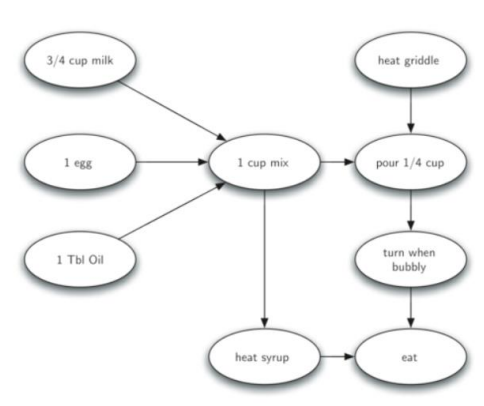

Напишите программу, которая при помощи поиска в глубину (Depth-first search, DFS)
проведет топологическую сортировку представленного графа и выдаст вариант корректной
последовательности шагов. Например:

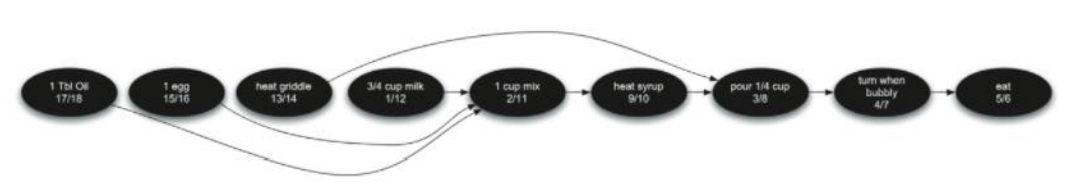

Используйте класс Graph из лекционных материалов.

In [11]:
def tpl_sort(graph):
    visited = set()
    stack = []

    def dfs(vertex_key):
        visited.add(vertex_key)
        vertex = graph.getVertex(vertex_key)
        for neighbor in vertex.get_edges():
            if neighbor not in visited:
                dfs(neighbor)
        stack.append(vertex_key)

    for v in graph.getVertices():
        if v not in visited:
            dfs(v)

    stack.reverse()
    return stack

g = Graph()
g.addEdge("3/4 cup milk", "1 cup mix")
g.addEdge("1 egg", "1 cup mix")
g.addEdge("1 tbl oil", "1 cup mix")
g.addEdge("1 cup mix", "pour 1/4 cup")
g.addEdge("heat griddle", "pour 1/4 cup")
g.addEdge("pour 1/4 cup", "turn when bubbly")
g.addEdge("turn when bubbly", "eat")
g.addEdge("1 cup mix", "heat syrup")
g.addEdge("heat syrup", "eat")

order = tpl_sort(g)
print("Корректная последовательность шагов:")
for step in order:
    print(step)


Корректная последовательность шагов:
heat griddle
1 tbl oil
1 egg
3/4 cup milk
1 cup mix
heat syrup
pour 1/4 cup
turn when bubbly
eat


№ 4(5 баллов) У вас имеется список городов и набор автобусных маршрутов между ними. Маршруты
однонаправленные, т.е. маршрут вида «город А – город Б» означает, что можно поехать из
города А в город Б, а обратного проезда нет.
Пользователь вводит два города. Ваша программа должна определить минимальный по
количеству километров возможный путь от первого до второго города, или сообщение, что
пути между городами нет. Нужно вывести как количество километров, так и получившейся
путь.
Для решения задачи используйте алгоритм Дейкстры и класс Graph из лекционных
материалов. Список городов и маршрутов возьмите согласно вашему варианту. Расстояние
между городами найдите в интернете самостоятельно.
Также необходимо нарисовать граф вашего варианта (например, здесь
https://graphonline.ru/) и приложить его в ваш отчет. 

Вариант 2.
Города:
Белово, Ленинск-Кузнецкий, Киселевск, Гурьевск, Мыски, Кемерово, Новосибирск.
Маршруты:
Белово – Ленинск-Кузнецкий
Белово – Гурьевск
Ленинск-Кузнецкий – Гурьевск
Ленинск-Кузнецкий – Мыски
Ленинск-Кузнецкий – Кемерово
Ленинск-Кузнецкий – Новосибирск
Киселевск – Ленинск-Кузнецкий
Киселевск – Новосибирск
Гурьевск – Мыски
Мыски – Кемерово
Новосибирск – Кемерово

In [15]:
import heapq

def dijkstra(graph, start, end):
    distances = {v: float('inf') for v in graph.getVertices()}
    previous = {v: None for v in graph.getVertices()}
    distances[start] = 0

    pq = [(0, start)]

    while pq:
        current_distance, current_vertex = heapq.heappop(pq)
        if current_distance > distances[current_vertex]:
            continue

        for neighbor, weight in graph.getVertex(current_vertex).get_edges().items():
            if weight is None:
                continue
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_vertex
                heapq.heappush(pq, (distance, neighbor))

    path = []
    current = end
    if distances[end] == float('inf'):
        return None, None
    while current is not None:
        path.insert(0, current)
        current = previous[current]
    return distances[end], path

g = Graph()
cities = ["Белово", "Ленинск-Кузнецкий", "Киселевск", "Гурьевск", "Мыски", "Кемерово", "Новосибирск"]
for city in cities:
    g.addVertex(Vertex(city))

g.addEdge("Белово", "Ленинск-Кузнецкий", 39.1)
g.addEdge("Белово", "Гурьевск", 31.9)
g.addEdge("Ленинск-Кузнецкий", "Гурьевск", 72.6)
g.addEdge("Ленинск-Кузнецкий", "Мыски", 203)
g.addEdge("Ленинск-Кузнецкий", "Кемерово", 88.6)
g.addEdge("Ленинск-Кузнецкий", "Новосибирск", 236)
g.addEdge("Киселевск", "Ленинск-Кузнецкий", 93.5)
g.addEdge("Киселевск", "Новосибирск", 328)
g.addEdge("Гурьевск", "Мыски", 205)
g.addEdge("Мыски", "Кемерово", 286)
g.addEdge("Новосибирск", "Кемерово", 269)

start_city = input("Введите город отправления: ").strip()
end_city = input("Введите город назначения: ").strip()

distance, path = dijkstra(g, start_city, end_city)
if path is None:
    print("Пути между городами нет.")
else:
    print(f"Минимальное расстояние: {distance} км")
    print("Путь:", " -> ".join(path))


Минимальное расстояние: 182.1 км
Путь: Киселевск -> Ленинск-Кузнецкий -> Кемерово
